# ✅ Solutions — Session 5: Data Storytelling & Dashboards

Worked solutions to all five exercises and the mini project.
Run each cell top to bottom.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Exercise 1 (Easy) — Two equivalent ways to plot a column

`ax.plot(df["month"], df["revenue"])` and `df.plot(x="month", y="revenue",
ax=ax)` draw the same line onto the same Axes.

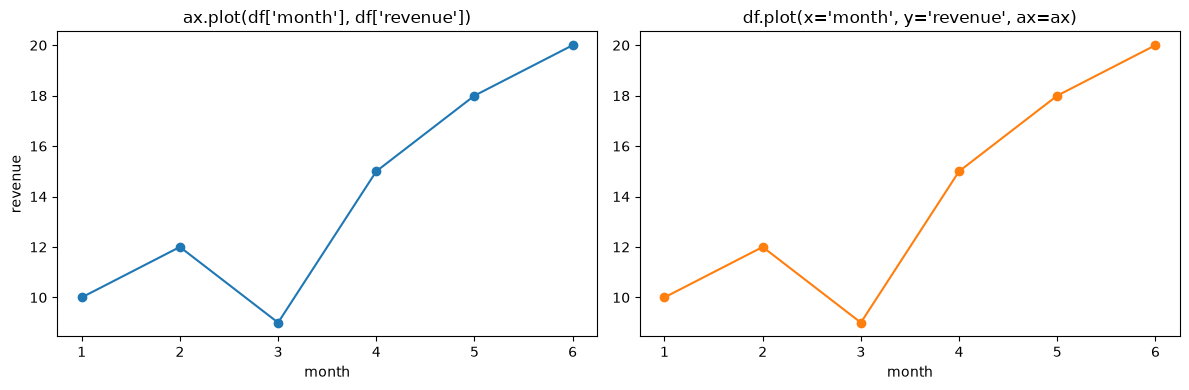

In [2]:
df = pd.DataFrame({
    "month": [1, 2, 3, 4, 5, 6],
    "revenue": [10, 12, 9, 15, 18, 20],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["month"], df["revenue"], marker="o", color="C0")
axes[0].set_title("ax.plot(df['month'], df['revenue'])")
axes[0].set_xlabel("month")
axes[0].set_ylabel("revenue")

df.plot(x="month", y="revenue", ax=axes[1], marker="o", color="C1", legend=False)
axes[1].set_title("df.plot(x='month', y='revenue', ax=ax)")
axes[1].set_xlabel("month")

fig.tight_layout()
plt.show()

## Exercise 2 (Easy) — Shared x-axis

With `sharex=True` the panels share one x-scale and only the bottom panel draws
x tick labels, so the two trends are read against exactly the same time axis.

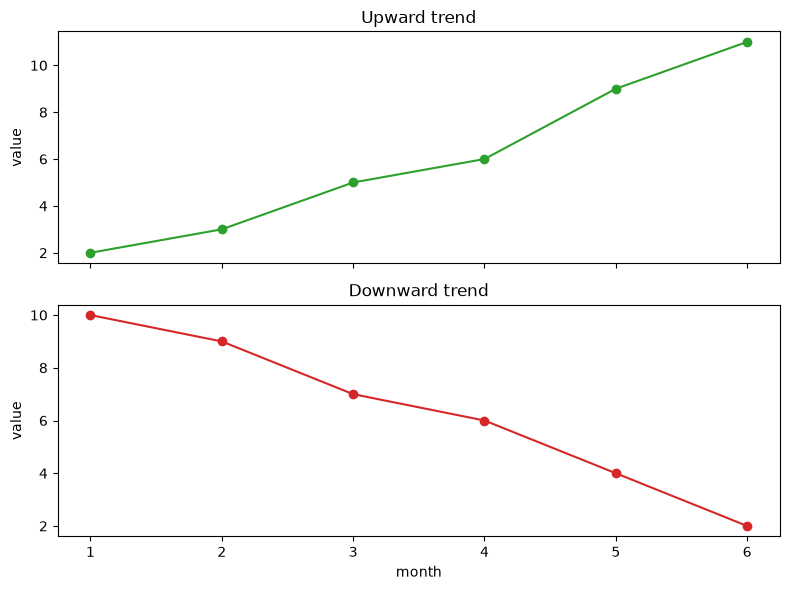

In [3]:
x = np.arange(1, 7)
up = np.array([2, 3, 5, 6, 9, 11])
down = np.array([10, 9, 7, 6, 4, 2])

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
axes[0].plot(x, up, marker="o", color="C2")
axes[0].set_title("Upward trend")
axes[0].set_ylabel("value")

axes[1].plot(x, down, marker="o", color="C3")
axes[1].set_title("Downward trend")
axes[1].set_xlabel("month")
axes[1].set_ylabel("value")

fig.tight_layout()
plt.show()

## Exercise 3 (Medium, coding) — Sorted, zero-based bar chart with labels

Sort bars by value, keep the y-axis zero-based, label each bar, and add a bold
title with a gray subtitle.

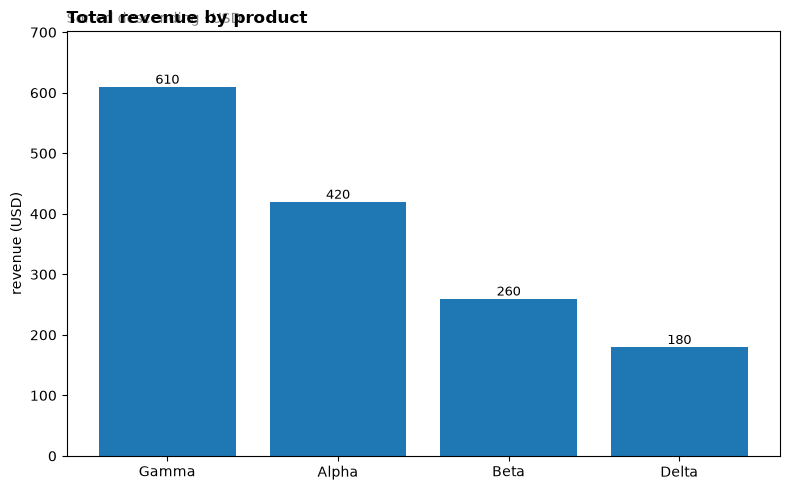

In [4]:
prod = pd.DataFrame({
    "product": ["Alpha", "Beta", "Gamma", "Delta"],
    "revenue": [420, 260, 610, 180],
})
ordered = prod.set_index("product")["revenue"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ordered.index, ordered.values, color="C0")
ax.set_ylim(0, ordered.max() * 1.15)
ax.set_title("Total revenue by product", loc="left", fontweight="bold")
ax.text(0, 1.02, "Sorted descending · USD", transform=ax.transAxes,
        fontsize=10, color="gray")
ax.set_ylabel("revenue (USD)")

for bar, value in zip(bars, ordered.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,.0f}",
            ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.show()

## Exercise 4 (Medium) — Annotate the peak and mark the mean

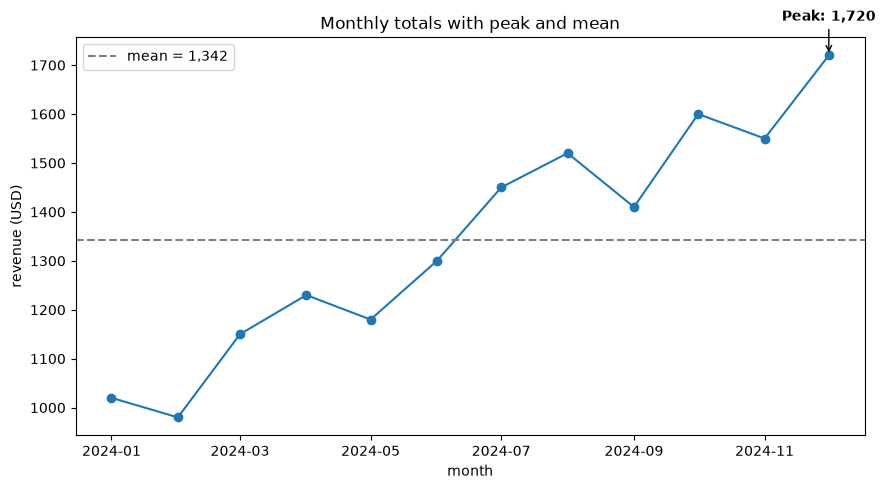

In [5]:
monthly = pd.Series(
    [1020, 980, 1150, 1230, 1180, 1300, 1450, 1520, 1410, 1600, 1550, 1720],
    index=pd.date_range("2024-01-01", periods=12, freq="MS"),
)

peak_month = monthly.idxmax()
peak_value = monthly.max()
mean_value = monthly.mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly.index, monthly.values, marker="o", color="C0")
ax.axhline(mean_value, linestyle="--", color="gray",
           label=f"mean = {mean_value:,.0f}")
ax.annotate(
    f"Peak: {peak_value:,.0f}",
    xy=(peak_month, peak_value),
    xytext=(0, 25),
    textcoords="offset points",
    ha="center",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax.set_title("Monthly totals with peak and mean")
ax.set_xlabel("month")
ax.set_ylabel("revenue (USD)")
ax.legend()
fig.tight_layout()
plt.show()

## Exercise 5 (Advanced, conceptual) — Why a truncated baseline misleads

A bar encodes a value by its **length**. When the y-axis starts at 90 instead
of 0, the visible length no longer represents the full quantity — only the part
above 90 — so a small difference can be drawn as a huge one. The reader
compares bar lengths automatically, and a truncated axis breaks that honest
encoding.

To redraw it honestly: start the y-axis at zero, label the axis with units, and
if the differences are genuinely tiny, show them with a line chart, a
difference plot, or a table instead of inflated bars. Adding the actual numbers
on or near the bars also removes any ambiguity.

A non-zero baseline **is** acceptable when the zero point is not meaningful for
the measure — for example, plotting a temperature anomaly, a price index, or a
percentage change around a reference value. In those cases the baseline is a
meaningful neutral line (say, the 0% change line), not an arbitrary cutoff.

## 🚀 Mini Project — Sales Dashboard

Generate the data inline, build the four panels, add the story layers, and
export a publication-quality PNG that is removed afterward.

In [6]:
rng = np.random.default_rng(42)
months = pd.date_range("2024-01-01", periods=12, freq="MS")
base = {"Alpha": 120, "Beta": 90, "Gamma": 60}

records = []
for product, start in base.items():
    for i, month in enumerate(months):
        trend = start * (1 + 0.04 * i)
        seasonal = 1 + 0.25 * np.sin(2 * np.pi * i / 12)
        revenue = trend * seasonal * rng.normal(1.0, 0.05)
        records.append({"month": month, "product": product, "revenue": round(revenue, 2)})

sales = pd.DataFrame(records)
pivot = sales.pivot(index="month", columns="product", values="revenue")
total_by_product = sales.groupby("product")["revenue"].sum()
monthly_total = sales.groupby("month")["revenue"].sum()
peak_month = monthly_total.idxmax()
peak_value = monthly_total.max()

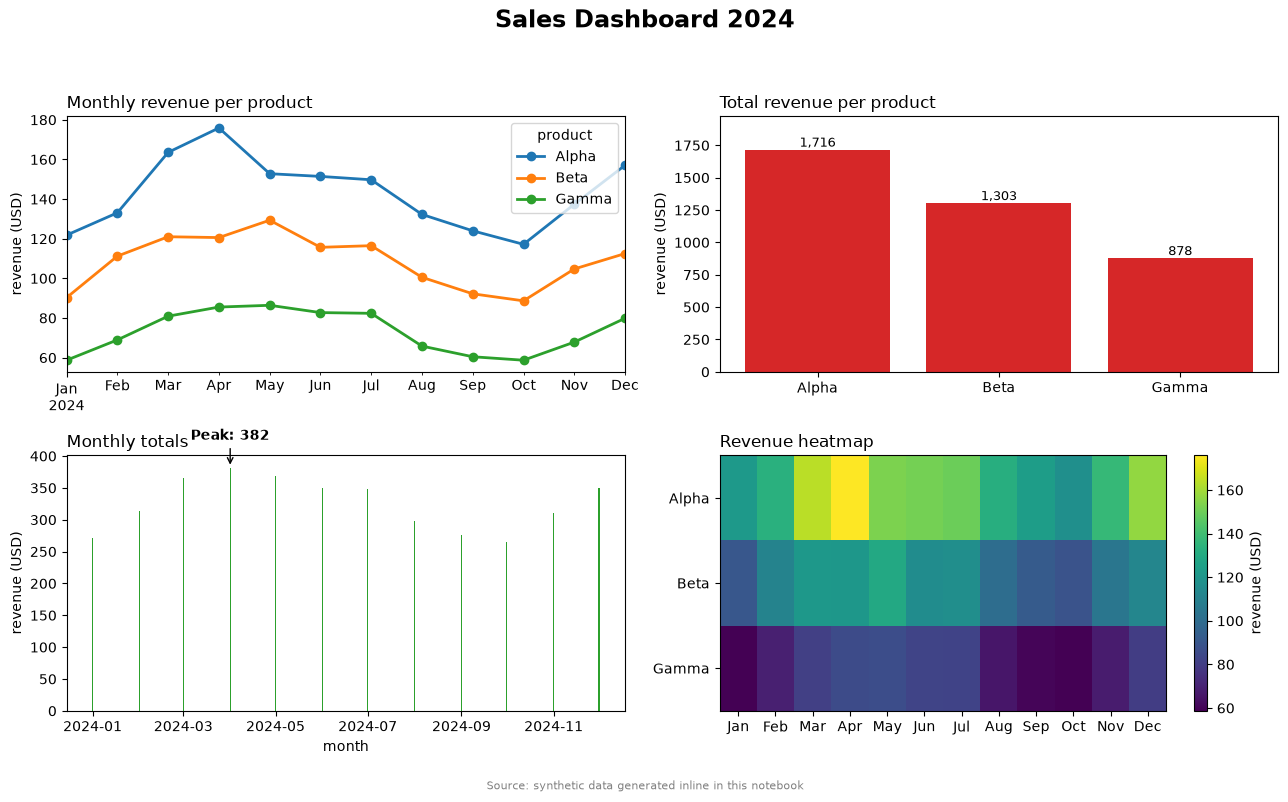

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- Top-left: revenue per product over time ---
pivot.plot(ax=axes[0, 0], marker="o", linewidth=2)
axes[0, 0].set_title("Monthly revenue per product", loc="left")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("revenue (USD)")

# --- Top-right: total revenue per product ---
ordered = total_by_product.sort_values(ascending=False)
bars = axes[0, 1].bar(ordered.index, ordered.values, color="C3")
axes[0, 1].set_ylim(0, ordered.max() * 1.15)
axes[0, 1].set_title("Total revenue per product", loc="left")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("revenue (USD)")
for bar, value in zip(bars, ordered.values):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, value, f"{value:,.0f}",
                    ha="center", va="bottom", fontsize=9)

# --- Bottom-left: monthly totals with the peak annotated ---
axes[1, 0].bar(monthly_total.index, monthly_total.values, color="C2")
axes[1, 0].set_title("Monthly totals", loc="left")
axes[1, 0].set_xlabel("month")
axes[1, 0].set_ylabel("revenue (USD)")
axes[1, 0].annotate(
    f"Peak: {peak_value:,.0f}",
    xy=(peak_month, peak_value),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black"),
)

# --- Bottom-right: product x month heatmap ---
heat = axes[1, 1].imshow(pivot.T.values, aspect="auto", cmap="viridis")
axes[1, 1].set_yticks(range(len(pivot.columns)), labels=pivot.columns)
axes[1, 1].set_xticks(range(len(pivot.index)),
                       labels=[m.strftime("%b") for m in pivot.index])
axes[1, 1].set_title("Revenue heatmap", loc="left")
fig.colorbar(heat, ax=axes[1, 1], label="revenue (USD)")

# --- Story layers ---
fig.suptitle("Sales Dashboard 2024", fontsize=17, fontweight="bold")
fig.text(0.5, 0.005, "Source: synthetic data generated inline in this notebook",
         ha="center", fontsize=8, color="gray")
fig.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

In [8]:
import os

fig.savefig("sales_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()
os.remove("sales_dashboard.png")
print("Saved and removed sales_dashboard.png")

Saved and removed sales_dashboard.png
